# SSNP Intensity Diffraction Tomography

This notebook demonstrates the Split-Step Non-Paraxial (SSNP) forward model
for Intensity Diffraction Tomography (IDT), and its use for reconstructing
the 3D refractive index (RI) distribution of a biological sample from
intensity-only measurements.

**Reference:** Zhu, Wang & Tian, *Optics Express* 30(18), 32808-32821 (2022)

## Overview

1. Load precomputed results (runs in seconds)
2. Visualize the ground truth phantom
3. Inspect simulated IDT measurements (8 angles, NA=0.65)
4. Compare reconstruction against ground truth
5. Evaluate quantitative metrics

> To run the full pipeline from scratch, uncomment the cells marked with `# FULL PIPELINE`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load Precomputed Results

These were generated by `python main.py` and stored in `evaluation/reference_outputs/`.

In [2]:
ref_dir = os.path.join("..", "evaluation", "reference_outputs")

ground_truth = np.load(os.path.join(ref_dir, "ground_truth.npy"))
measurements = np.load(os.path.join(ref_dir, "measurements.npy"))
reconstruction = np.load(os.path.join(ref_dir, "reconstruction.npy"))
loss_history = np.load(os.path.join(ref_dir, "loss_history.npy"))

with open(os.path.join(ref_dir, "metrics.json")) as f:
    metrics = json.load(f)

# Load metadata
with open(os.path.join("..", "data", "meta_data")) as f:
    metadata = json.load(f)

print(f"Ground truth shape : {ground_truth.shape}")
print(f"Measurements shape : {measurements.shape}")
print(f"Reconstruction shape: {reconstruction.shape}")
print(f"Loss history length : {len(loss_history)}")
print(f"\nMetadata:")
for k, v in metadata.items():
    if k != 'description':
        print(f"  {k}: {v}")

Ground truth shape : (308, 256, 256)
Measurements shape : (8, 256, 256)
Reconstruction shape: (308, 256, 256)
Loss history length : 10

Metadata:
  volume_shape: [308, 256, 256]
  res_um: [0.1, 0.1, 0.1]
  wavelength_um: 0.5
  n0: 1.0
  NA: 0.65
  n_angles: 8
  ri_contrast_scale: 0.01
  tiff_scale: 1.0


## 2. Ground Truth Phantom

The phantom is a 308x256x256 volume with RI contrast $\Delta n$ up to 0.01.
It contains concentric ring/tube structures that serve as a test target for the SSNP-IDT algorithm.

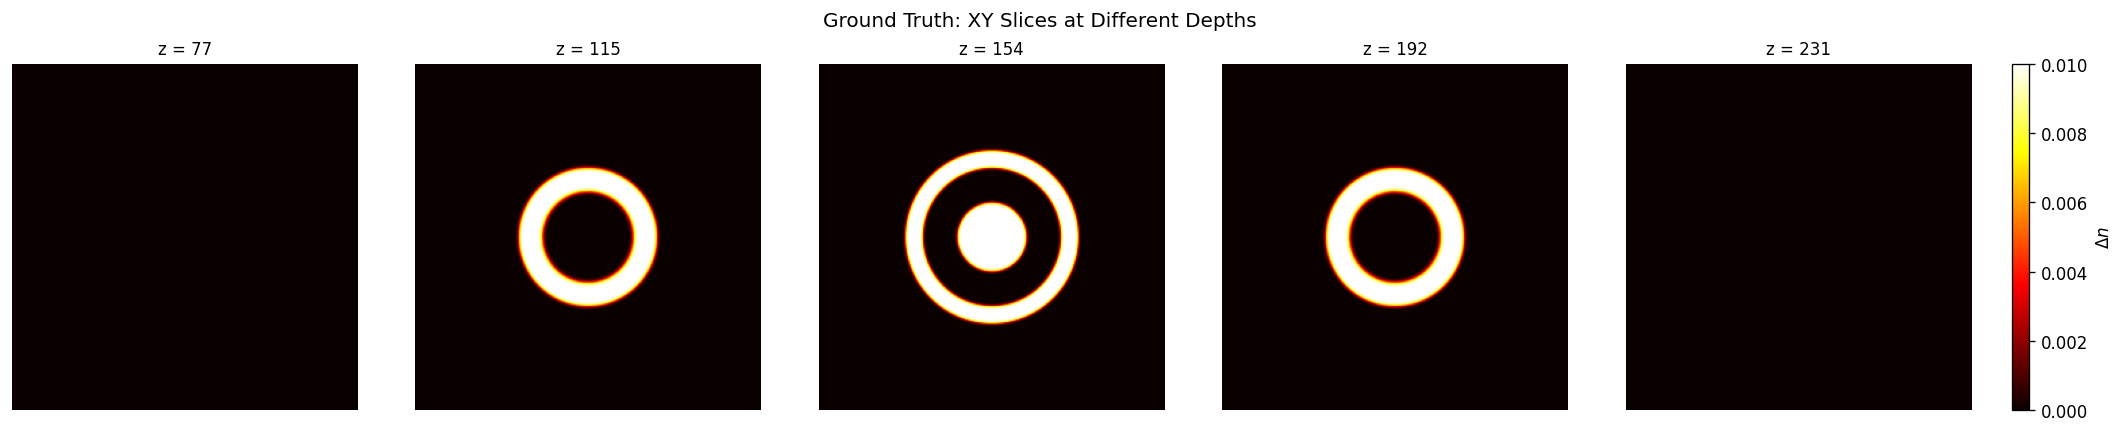

In [3]:
nz, ny, nx = ground_truth.shape
vmax_gt = np.percentile(ground_truth, 99.5)

# XY slices at 5 different z positions
z_indices = [nz//4, 3*nz//8, nz//2, 5*nz//8, 3*nz//4]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), constrained_layout=True)
for ax, zi in zip(axes, z_indices):
    im = ax.imshow(ground_truth[zi], cmap='hot', origin='lower',
                   vmin=0, vmax=vmax_gt)
    ax.set_title(f'z = {zi}', fontsize=10)
    ax.axis('off')
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='$\\Delta n$')
fig.suptitle('Ground Truth: XY Slices at Different Depths', fontsize=12)
plt.show()

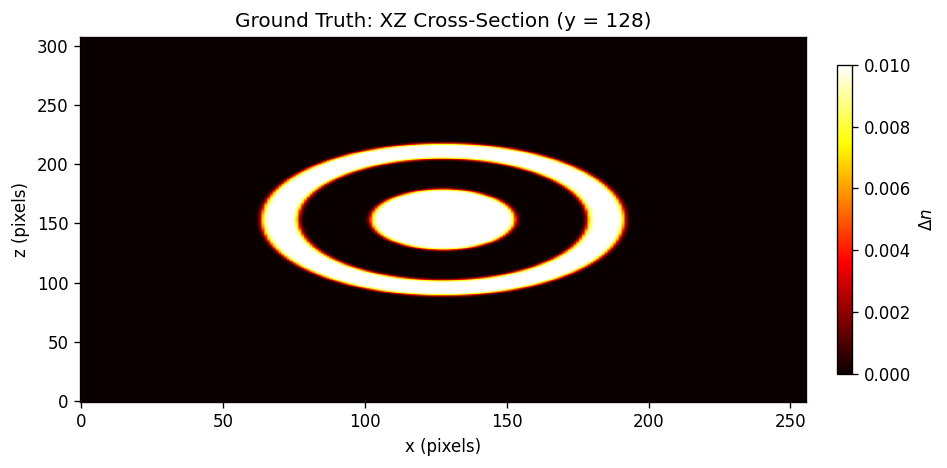

In [4]:
# XZ cross-section through the centre
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(ground_truth[:, ny//2, :], cmap='hot', origin='lower',
               vmin=0, vmax=vmax_gt, aspect='auto')
ax.set_xlabel('x (pixels)')
ax.set_ylabel('z (pixels)')
ax.set_title(f'Ground Truth: XZ Cross-Section (y = {ny//2})')
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.04, label='$\\Delta n$')
plt.tight_layout()
plt.show()

## 3. Simulated IDT Measurements

8 intensity images captured under annular LED illumination at NA = 0.65.
Each LED produces a tilted plane wave at a different azimuthal angle.
The measured intensity shows angle-dependent diffraction patterns.

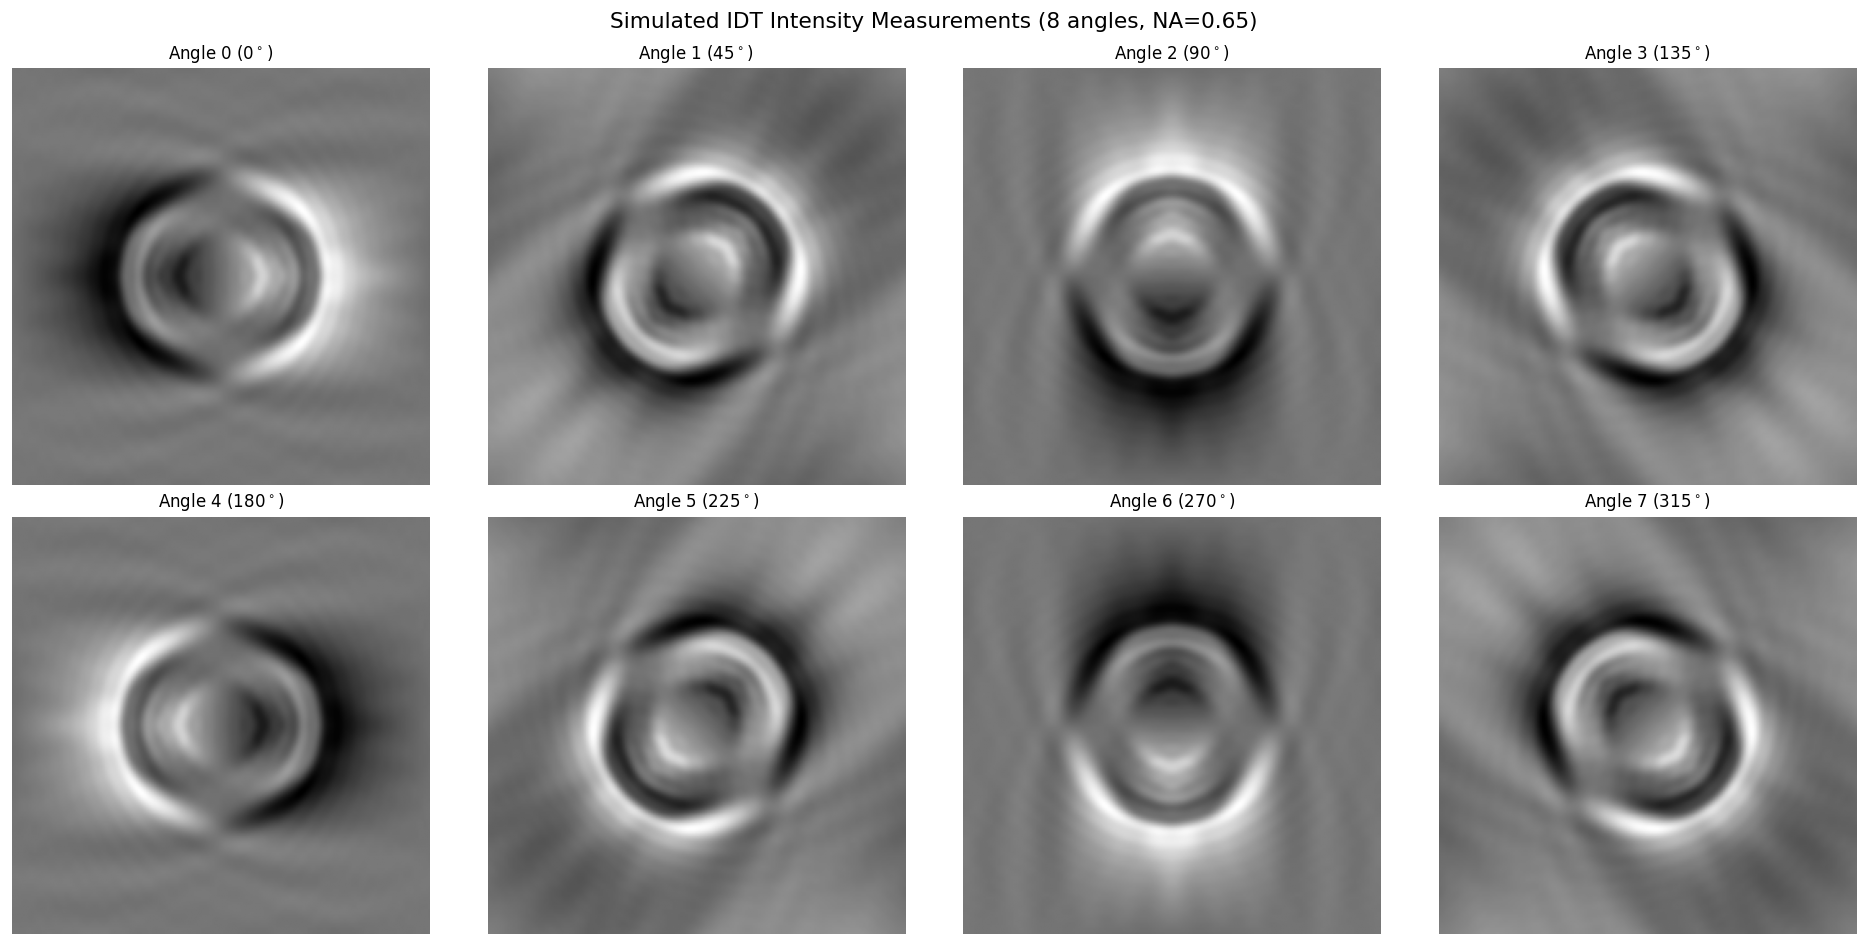

Intensity range: [0.6343, 1.4205]
Mean intensity:  0.9951


In [5]:
n_angles = measurements.shape[0]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(n_angles):
    r, c = divmod(i, 4)
    theta_deg = 360 * i / n_angles
    axes[r, c].imshow(measurements[i], cmap='gray', origin='lower')
    axes[r, c].set_title(f'Angle {i} ({theta_deg:.0f}$^\\circ$)', fontsize=10)
    axes[r, c].axis('off')

fig.suptitle('Simulated IDT Intensity Measurements (8 angles, NA=0.65)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Intensity range: [{measurements.min():.4f}, {measurements.max():.4f}]")
print(f"Mean intensity:  {measurements.mean():.4f}")

## 4. Reconstruction Results

The 3D RI is recovered using gradient descent on the amplitude-domain MSE loss,
with the SSNP forward model providing the gradient via automatic differentiation (PyTorch autograd).

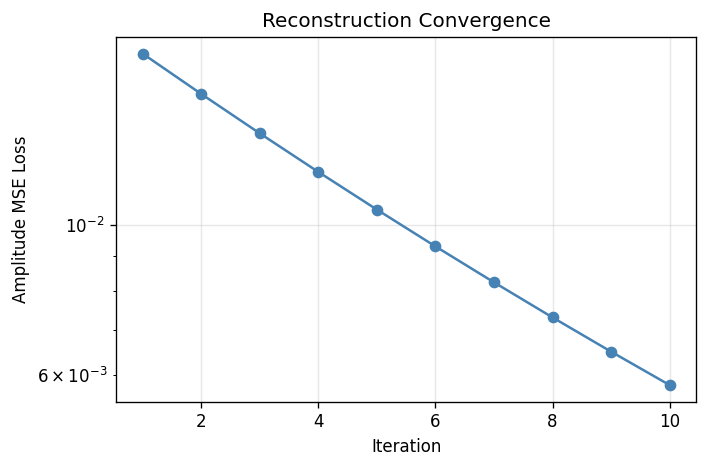

Initial loss: 0.017943
Final loss:   0.005800
Reduction:    3.1x


In [6]:
# Loss convergence
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(loss_history)+1), loss_history, 'o-', color='steelblue', lw=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Amplitude MSE Loss')
ax.set_title('Reconstruction Convergence')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {loss_history[-1]:.6f}")
print(f"Reduction:    {loss_history[0]/loss_history[-1]:.1f}x")

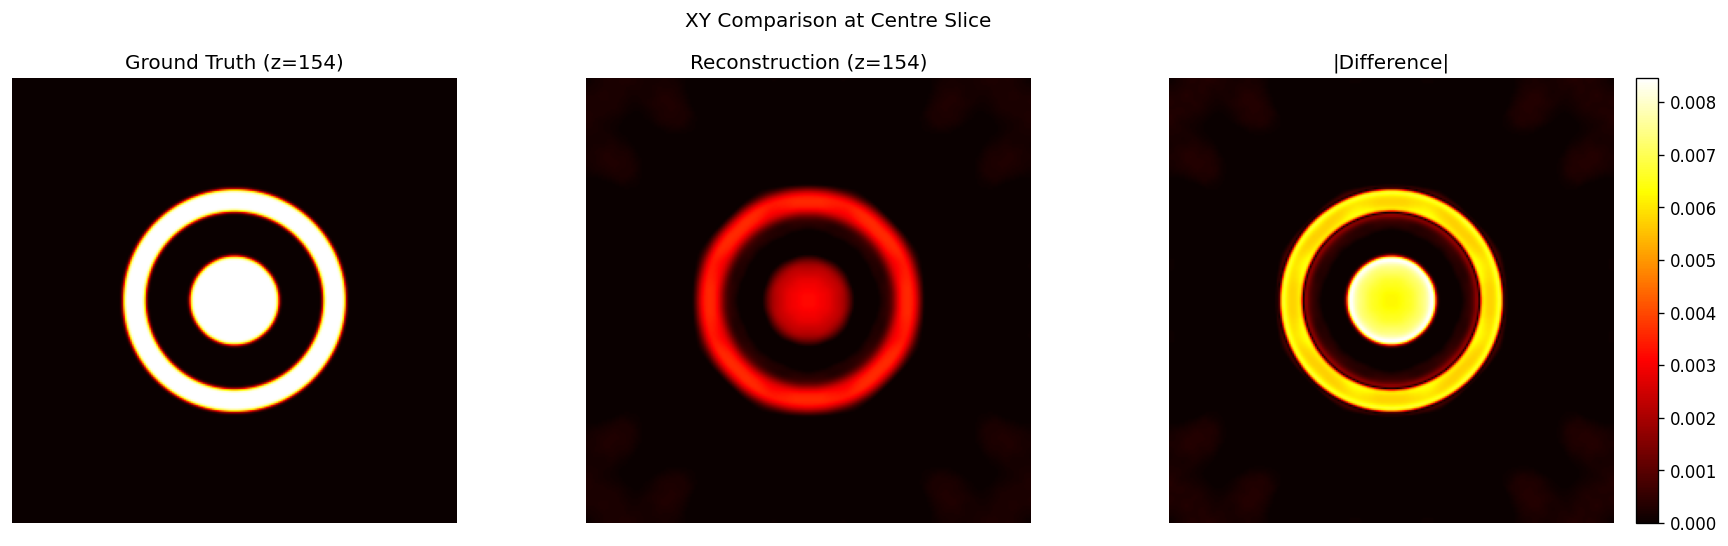

In [7]:
# Side-by-side comparison: XY slices
vmax = max(np.percentile(ground_truth, 99.5), np.percentile(reconstruction, 99.5))
z_mid = nz // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(ground_truth[z_mid], cmap='hot', origin='lower', vmin=0, vmax=vmax)
axes[0].set_title(f'Ground Truth (z={z_mid})')

axes[1].imshow(reconstruction[z_mid], cmap='hot', origin='lower', vmin=0, vmax=vmax)
axes[1].set_title(f'Reconstruction (z={z_mid})')

diff = np.abs(ground_truth[z_mid] - reconstruction[z_mid])
im = axes[2].imshow(diff, cmap='hot', origin='lower')
axes[2].set_title('|Difference|')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

fig.suptitle('XY Comparison at Centre Slice', fontsize=12)
plt.tight_layout()
plt.show()

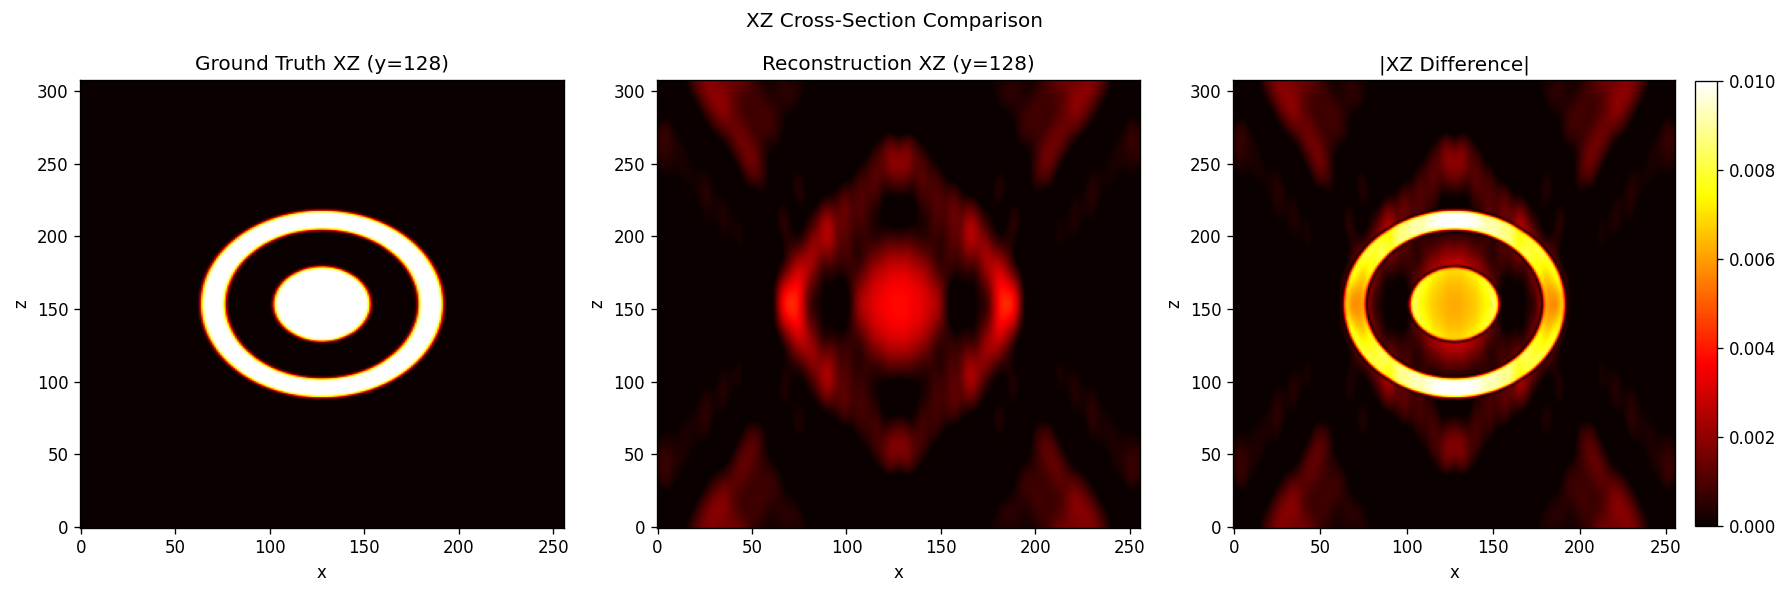

In [8]:
# XZ cross-section comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ground_truth[:, ny//2, :], cmap='hot', origin='lower',
               vmin=0, vmax=vmax, aspect='auto')
axes[0].set_title(f'Ground Truth XZ (y={ny//2})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('z')

axes[1].imshow(reconstruction[:, ny//2, :], cmap='hot', origin='lower',
               vmin=0, vmax=vmax, aspect='auto')
axes[1].set_title(f'Reconstruction XZ (y={ny//2})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('z')

diff_xz = np.abs(ground_truth[:, ny//2, :] - reconstruction[:, ny//2, :])
im = axes[2].imshow(diff_xz, cmap='hot', origin='lower', aspect='auto')
axes[2].set_title('|XZ Difference|')
axes[2].set_xlabel('x'); axes[2].set_ylabel('z')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle('XZ Cross-Section Comparison', fontsize=12)
plt.tight_layout()
plt.show()

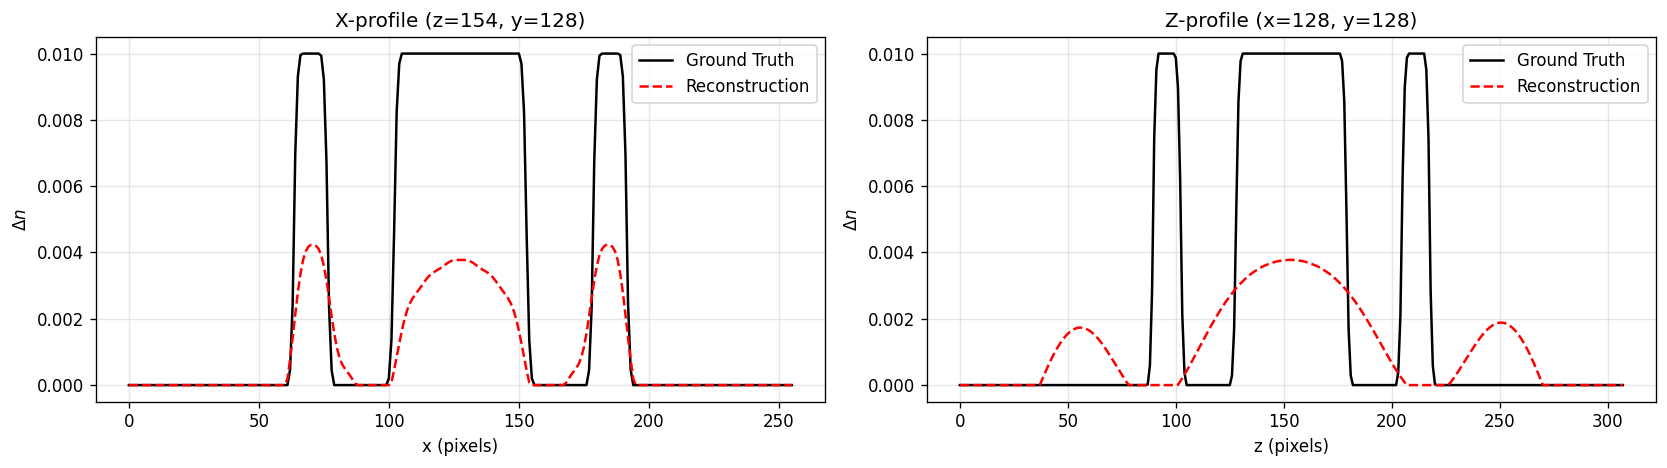

In [9]:
# Line profiles through the centre
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# X-profile at (z_mid, ny//2)
ax1.plot(ground_truth[z_mid, ny//2, :], 'k-', lw=1.5, label='Ground Truth')
ax1.plot(reconstruction[z_mid, ny//2, :], 'r--', lw=1.5, label='Reconstruction')
ax1.set_xlabel('x (pixels)')
ax1.set_ylabel('$\\Delta n$')
ax1.set_title(f'X-profile (z={z_mid}, y={ny//2})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Z-profile at (ny//2, nx//2)
ax2.plot(ground_truth[:, ny//2, nx//2], 'k-', lw=1.5, label='Ground Truth')
ax2.plot(reconstruction[:, ny//2, nx//2], 'r--', lw=1.5, label='Reconstruction')
ax2.set_xlabel('z (pixels)')
ax2.set_ylabel('$\\Delta n$')
ax2.set_title(f'Z-profile (x={nx//2}, y={ny//2})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Quantitative Evaluation

In [10]:
print("Reconstruction Metrics")
print("=" * 30)
print(f"  NRMSE : {metrics['nrmse']:.4f}")
print(f"  NCC   : {metrics['ncc']:.4f}")
print(f"  SSIM  : {metrics['ssim']:.4f}")
print()
print("Notes:")
print("  - NRMSE < 1.0 indicates meaningful recovery")
print("  - NCC > 0.7 indicates good structural similarity")
print("  - The 'diamond' shape in XZ is the missing-cone artifact")
print("    from limited angular coverage (8 angles at NA=0.65)")

Reconstruction Metrics
  NRMSE : 0.7949
  NCC   : 0.7217
  SSIM  : 0.6084

Notes:
  - NRMSE < 1.0 indicates meaningful recovery
  - NCC > 0.7 indicates good structural similarity
  - The 'diamond' shape in XZ is the missing-cone artifact
    from limited angular coverage (8 angles at NA=0.65)


## 6. Run Full Pipeline (Optional)

Uncomment and run the following cells to reproduce the results from scratch.
Requires a GPU for reasonable runtime (~2 min on an RTX 3090).

In [11]:
# # FULL PIPELINE - Uncomment to run from scratch
# import sys
# sys.path.insert(0, '..')
# import torch
# from src.preprocessing import prepare_data
# from src.physics_model import SSNPConfig, SSNPForwardModel
# from src.solvers import SSNPReconstructor
# from src.visualization import compute_metrics, print_metrics_table
#
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f'Device: {device}')
#
# # Load data
# phantom_dn, metadata = prepare_data(os.path.join('..', 'data'))
# config = SSNPConfig.from_metadata(metadata)
# model = SSNPForwardModel(config, device=device)
#
# # Simulate measurements
# dn_tensor = torch.tensor(phantom_dn, dtype=torch.float64, device=device)
# with torch.no_grad():
#     meas_tensor = model.forward(dn_tensor)
#
# # Reconstruct
# meas_amp = torch.sqrt(meas_tensor)
# reconstructor = SSNPReconstructor(n_iter=10, lr=50.0, device=device)
# dn_recon, loss_hist = reconstructor.reconstruct(meas_amp, model)
#
# # Evaluate
# m = compute_metrics(dn_recon, phantom_dn)
# print_metrics_table(m)

## Summary

This notebook demonstrated the SSNP-IDT pipeline:

1. **Forward model**: The SSNP model propagates a tilted plane wave through the 3D sample
   using alternating diffraction (P, Fourier space) and scattering (Q, real space) operators,
   then extracts the forward-propagating intensity at the camera.

2. **Measurements**: 8 intensity images under annular illumination at NA = 0.65 show
   clear angle-dependent diffraction patterns from the phantom structure.

3. **Reconstruction**: Gradient descent on the amplitude-domain MSE loss recovers the
   ring structure with correct RI contrast. The gradient is computed automatically via
   PyTorch autograd through the entire forward model.

4. **Limitations**: The missing-cone artifact (diamond shape in XZ) is inherent to
   limited-angle tomography and cannot be removed without additional regularization
   or more measurement angles.